Enter starting location: Home
Enter destination: Station

Shortest Path: Home -> Market -> Hospital -> Station
Total Distance: 11 km


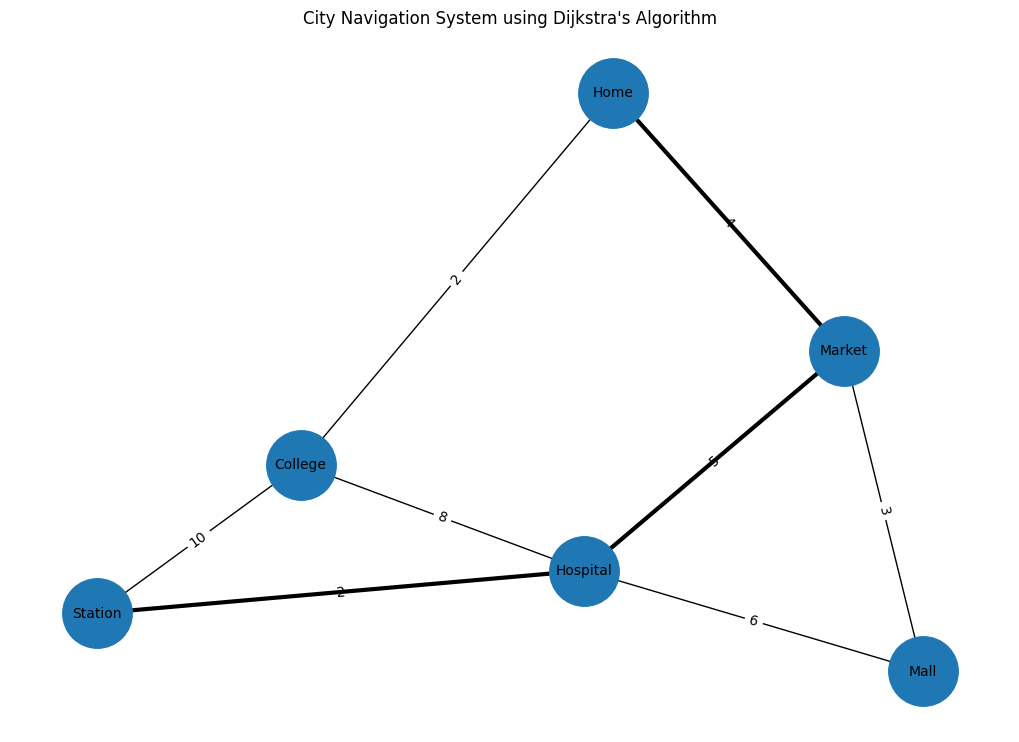

In [4]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra(graph, start):
    priority_queue = [(0, start)]
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))

    return distances, previous

def get_path(previous, start, end):
    path = []
    current = end

    while current is not None:
        path.append(current)
        current = previous[current]

    path.reverse()
    if path[0] == start:
        return path
    return []

graph = {
    'Home': {'Market': 4, 'College': 2},
    'Market': {'Home': 4, 'Hospital': 5, 'Mall': 3},
    'College': {'Home': 2, 'Hospital': 8, 'Station': 10},
    'Hospital': {'Market': 5, 'College': 8, 'Station': 2, 'Mall': 6},
    'Station': {'College': 10, 'Hospital': 2},
    'Mall': {'Market': 3, 'Hospital': 6}
}

start = input("Enter starting location: ")
end = input("Enter destination: ")

if start in graph and end in graph:
    distances, previous = dijkstra(graph, start)
    path = get_path(previous, start, end)

    if path:
        print("\nShortest Path:", " -> ".join(path))
        print("Total Distance:", distances[end], "km")

        G = nx.Graph()

        for node in graph:
            for neighbor, weight in graph[node].items():
                G.add_edge(node, neighbor, weight=weight)

        pos = nx.spring_layout(G, seed=42)
        edge_labels = nx.get_edge_attributes(G, 'weight')

        plt.figure(figsize=(10, 7))
        nx.draw(G, pos, with_labels=True, node_size=2500, font_size=10)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=3)

        plt.title("City Navigation System using Dijkstra's Algorithm")
        plt.show()
    else:
        print("No path found.")
else:
    print("Invalid location entered.")